# Multimodal Short-Video Recommendation System

This project aims to build a recommendation system to improve content relevance on a mobile short-video platform. The system predicts user engagement with candidate videos, measured by watch ratio, which is then used to rank candidate videos and recommend the most relevant content to users.

In [ ]:
%pip install -q torch tqdm

import os, re, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | PyTorch: {torch.__version__}")

Device: cuda | PyTorch: 2.10.0+cu128


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

BASE      = os.environ.get("BT4222_DATA_DIR", "/content/drive/MyDrive/BT4222 Final Proj/BT4222 Data/")
if not BASE.endswith(os.sep): BASE += os.sep
ARTIFACTS = BASE.replace("BT4222 Data/", "artifacts2/")
os.makedirs(ARTIFACTS, exist_ok=True)
print(f"BASE:      {BASE}")
print(f"ARTIFACTS: {ARTIFACTS}")

Mounted at /content/drive
BASE:      /content/drive/MyDrive/BT4222 Final Proj/BT4222 Data/
ARTIFACTS: /content/drive/MyDrive/BT4222 Final Proj/artifacts2/


### 6.1 Load Data

Section 6.1 loads the pre-engineered train/validation/test CSV splits and sorts each by `(user_id, exposed_time)` to preserve chronological order. It runs sanity checks to confirm the `watch_ratio` target is capped at 2.0 and that required columns (`user_id`, `pid`, `exposed_time`, `watch_ratio`) exist in every split. It then computes the full item and user vocabulary sizes.

Next, it builds **per-user interaction sequences** by grouping item IDs (`pid`) in time order — using *all* interactions regardless of watch ratio, since even brief views carry signal for sequence modelling. Finally, it constructs the **evaluation targets**: for each user, the set of positively-engaged items (`watch_ratio >= 0.3`) in the validation and test sets. For test evaluation, it merges train + validation histories chronologically so the model has a fuller picture of user behaviour at test time.

In [ ]:
# ── Load engineered splits (same as NMF and SASRec v2) ──
train_df = pd.read_csv(BASE + "train_engineered.csv")
val_df   = pd.read_csv(BASE + "val_engineered.csv")
test_df  = pd.read_csv(BASE + "test_engineered.csv")

for df in [train_df, val_df, test_df]:
    df.sort_values(["user_id", "exposed_time"], inplace=True)

print(f"Train: {train_df.shape}  Val: {val_df.shape}  Test: {test_df.shape}")

# ── Alignment check 1: watch_ratio cap ──
assert train_df['watch_ratio'].max() <= 2.01, "watch_ratio exceeds [0,2] cap — check preprocessing"
print(f"watch_ratio max: {train_df['watch_ratio'].max():.3f}  ✓ within [0, 2]")

# ── Alignment check 2: columns present ──
required = {'user_id', 'pid', 'exposed_time', 'watch_ratio'}
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert required.issubset(df.columns), f"Missing columns in {name}: {required - set(df.columns)}"
print("Required columns present in all splits ✓")

# ── num_items: full vocab across all splits (matches SASRec v2) ──
num_items = int(max(train_df['pid'].max(), val_df['pid'].max(), test_df['pid'].max())) + 1
num_users = int(max(train_df['user_id'].max(), val_df['user_id'].max(), test_df['user_id'].max())) + 1
print(f"num_items (full vocab): {num_items:,}")
print(f"num_users (full vocab): {num_users:,}")

Train: (800827, 29)  Val: (128091, 29)  Test: (90650, 29)
watch_ratio max: 2.000  ✓ within [0, 2]
Required columns present in all splits ✓
num_items (full vocab): 153,561
num_users (full vocab): 10,000


In [ ]:
# ── Build sequences from ALL training interactions (no threshold filter) ──
# Matches SASRec v2: uses all pids regardless of watch_ratio for the sequence
# Rationale: a user browsing briefly still signals item preference for sequence modelling
def sequences_by_user(df):
    return df.groupby("user_id", sort=False)["pid"].apply(list).to_dict()

train_seq = sequences_by_user(train_df)
val_seq   = sequences_by_user(val_df)
test_seq  = sequences_by_user(test_df)

print(f"Users with train seq: {len(train_seq):,}")
print(f"Users with val   seq: {len(val_seq):,}")
print(f"Users with test  seq: {len(test_seq):,}")
print(f"Median train seq len: {np.median([len(v) for v in train_seq.values()]):.0f}")

# ── Alignment check 3: sequence counts match SASRec v2 expected output ──
# v2 output: Users with train seq: 9701
if len(train_seq) != 9701:
    print(f"Note: train seq count {len(train_seq)} differs from v2 (9701). Check if same CSV version.")
else:
    print("Train seq count matches SASRec v2 ✓")

Users with train seq: 9,701
Users with val   seq: 6,314
Users with test  seq: 6,075
Median train seq len: 41
Train seq count matches SASRec v2 ✓


In [ ]:
# ── Test targets: all positive user interactions ──
# Val:  history = train seq only
# Test: history = train + val merged chronologically
first_val  = val_df[val_df['watch_ratio'] >= 0.3].groupby('user_id')['pid'].apply(set).to_dict()
first_test = test_df[test_df['watch_ratio'] >= 0.3].groupby('user_id')['pid'].apply(set).to_dict()
print(f"Val  targets: {len(first_val):,} users")
print(f"Test targets: {len(first_test):,} users")

# Build combined train+val history for test evaluation
def get_test_history(user_id):
    tr = train_seq.get(user_id, [])
    va = val_seq.get(user_id, [])
    if not va:
        return list(tr)
    # Merge with timestamps to ensure correct order
    t_tr = train_df.loc[train_df['user_id'] == user_id, ['exposed_time', 'pid']]
    t_va = val_df.loc[val_df['user_id'] == user_id, ['exposed_time', 'pid']]
    merged = pd.concat([t_tr, t_va]).sort_values('exposed_time')
    return merged['pid'].tolist()

# Pre-compute for all test users (expensive but correct)
print("Pre-computing test histories (train+val merged)...")
test_histories = {u: get_test_history(u) for u in tqdm(first_test)}
print(f"Test histories built for {len(test_histories):,} users")

Val  targets: 6,314
Test targets: 6,075
Pre-computing test histories (train+val merged)...


100%|██████████| 6075/6075 [00:28<00:00, 215.59it/s]

Test histories built for 6,075 users


### 6.2 Evaluation Utilities

Section 6.2 defines the ranking evaluation metrics used throughout the notebook:

- **NDCG@K** (Normalized Discounted Cumulative Gain): Measures ranking quality by giving higher credit to relevant items placed at the top of the list.
- **Recall@K**: The fraction of a user's positive items that appear in the top-K recommendations.
- **Precision@K**: The fraction of top-K recommendations that are actually positive items.

The `evaluate_model` function takes any model's top-K retrieval function and the ground-truth positive items, then computes all three metrics averaged across users. `print_metrics` formats the results into a readable table. These utilities are reused by every model variant later in the notebook.

In [ ]:
def ndcg_at_k(rel, k):
    rel = np.asarray(rel[:k], dtype=float)
    if not rel.size: return 0.0
    dcg  = (rel / np.log2(np.arange(2, rel.size + 2))).sum()
    idcg = (np.sort(rel)[::-1] / np.log2(np.arange(2, rel.size + 2))).sum()
    return dcg / idcg if idcg > 0 else 0.0

def recall_at_k_single(ranked_items, target_pid, k):
    return int(target_pid in set(ranked_items[:k]))

def evaluate_model(get_topk_fn, targets, K_list=(10, 20, 50)):
    """
    get_topk_fn(user_id, k) -> list of pids ranked best-first
    targets: {user_id: set of positive pids}
    """
    results = {K: {"Recall": [], "NDCG": [], "Precision": []} for K in K_list}
    for u, pos_set in tqdm(targets.items(), desc="Evaluating", leave=False):
        if not pos_set: continue
        max_k = max(K_list)
        ranked = get_topk_fn(u, max_k)
        for K in K_list:
            top_k = ranked[:K]
            hits  = len(set(top_k) & pos_set)
            rel   = [1 if p in pos_set else 0 for p in top_k]
            results[K]["Recall"].append(hits / len(pos_set))
            results[K]["NDCG"].append(ndcg_at_k(rel, K))
            results[K]["Precision"].append(hits / K)
    return {K: {m: float(np.mean(v)) for m, v in results[K].items()} for K in K_list}

def print_metrics(label, results, K_list=(10, 20, 50)):
    print(f"\n{'='*62}\n  {label}\n{'='*62}")
    print(f"{'Metric':<12}", end="")
    for K in K_list: print(f"  {'@'+str(K):>8}", end="")
    print(); print("-" * 44)
    for m in ["Recall", "NDCG", "Precision"]:
        print(f"{m:<12}", end="")
        for K in K_list: print(f"  {results[K][m]:>8.4f}", end="")
        print()

### 6.3 Load LightGCN Candidates

Section 6.3 loads the **Stage 1 candidate set** — the top-200 items per user generated by a separately trained LightGCN model (a graph-based collaborative filtering approach). It reads these from a saved CSV, verifies that every user has exactly 200 candidates, and organises them into a dictionary mapping each user to their ranked candidate list.

It then evaluates LightGCN as a standalone recommender on the test set, establishing the **baseline performance** that the Stage 2 re-rankers (SASRec and BPR-SASRec) will attempt to improve upon.

In [ ]:
cands_path = ARTIFACTS + "lightgcn_candidates_top200.csv"

# ── check LightGCN candidates file exists ──
if not os.path.exists(cands_path):
    raise FileNotFoundError(
        f"LightGCN candidates not found at {cands_path}\n"
        "Run lightgcn_model.ipynb first and ensure it saves to ARTIFACTS."
    )

cands_df = pd.read_csv(cands_path)
print(f"Loaded {len(cands_df):,} candidate rows")
print(f"Users covered: {cands_df['user_id'].nunique():,}")
print(f"Candidates per user: {cands_df.groupby('user_id').size().describe().to_dict()}")

# Build {user_id: [pid ranked 1..200]}
lgn_cands = (cands_df.sort_values(['user_id', 'rank'])
                      .groupby('user_id')['pid'].apply(list).to_dict())

sample_u = list(lgn_cands.keys())[0]
sample_p = lgn_cands[sample_u][0]
assert isinstance(sample_p, (int, np.integer)), f"Expected int pid, got {type(sample_p)}"
print(f"Sample — user {sample_u} top-5 pids: {lgn_cands[sample_u][:5]}  ✓ raw int PIDs")

Loaded 1,889,800 candidate rows
Users covered: 9,449
Candidates per user: {'count': 9449.0, 'mean': 200.0, 'std': 0.0, 'min': 200.0, '25%': 200.0, '50%': 200.0, '75%': 200.0, 'max': 200.0}
Sample — user 0 top-5 pids: [115135, 127914, 81849, 133408, 108192]  ✓ raw int PIDs


In [ ]:
# ── Evaluate LightGCN standalone (loaded candidates, no retraining needed) ──
# Uses the same first-target evaluation design as SASRec

# Build training positives per user for masking (raw pids)
train_pos_raw = train_df[train_df['watch_ratio'] >= 0.3].groupby('user_id')['pid'].apply(set).to_dict()

def lgn_topk(user_id, k):
    cands = lgn_cands.get(user_id, [])
    return cands[:k]

lgn_results = evaluate_model(lgn_topk, first_test, K_list=[10, 20, 50])
print_metrics("Stage 1: LightGCN alone (from saved candidates)", lgn_results)


  Stage 1: LightGCN alone (from saved candidates)
Metric             @10       @20       @50
--------------------------------------------
Recall          0.0048    0.0081    0.0161
NDCG            0.0025    0.0033    0.0049
Precision       0.0005    0.0004    0.0003


### 6.4 SASRec (ID-Only)

Section 6.4 implements and evaluates the **SASRec (Self-Attentive Sequential Recommendation)** model using item IDs only:

1. **Model architecture**: A Transformer encoder that takes a user's recent item sequence (up to 50 items), applies learned item + positional embeddings, processes them through 2 self-attention layers with a **causal mask** (so each position can only attend to earlier items), and outputs a score distribution over all items for next-item prediction.
2. **Training data**: Sliding-window samples from every user's training sequence — each prefix predicts the next item, using cross-entropy loss. This yields ~791K training samples.
3. **Training loop**: Uses Adam optimizer with cosine annealing, gradient clipping, and early stopping based on Recall@10 on the validation set (patience = 3 epochs).
4. **Standalone evaluation**: SASRec scores all items in the catalogue for each test user and retrieves the top-K (masking out training positives).
5. **Two-stage evaluation**: LightGCN first nominates 200 candidates, then SASRec re-ranks them — combining collaborative filtering breadth with sequential modelling precision.

In [ ]:
# ── Derive num_items from full pid vocabulary ──
# Needed here in case this cell is run independently or session was reset
num_items = int(pd.concat([train_df, val_df, test_df])['pid'].max()) + 1
print(f'num_items (full vocab): {num_items:,}')

MAX_LEN = 50

def to_emb_ids(pid_list):
    return [int(p) + 1 for p in pid_list]

def pad_seq(seq, max_len):
    return seq[-max_len:] if len(seq) >= max_len else [0] * (max_len - len(seq)) + seq

class SASRec(nn.Module):
    def __init__(self, num_items, emb_dim=64, max_len=50,
                 nhead=2, n_layers=2, dim_ff=256, dropout=0.2):
        super().__init__()
        self.item_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.pos_emb  = nn.Embedding(max_len, emb_dim)
        enc = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers,
                                                  norm=nn.LayerNorm(emb_dim))
        # Causal mask: prevents attending to future tokens
        self.register_buffer("causal_mask",
            torch.triu(torch.ones(max_len, max_len), diagonal=1).bool())
        self.out = nn.Linear(emb_dim, num_items)
        self._init()

    def _init(self):
        nn.init.normal_(self.item_emb.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight,  std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, seq):
        B, L  = seq.shape
        pos   = torch.arange(L, device=seq.device).unsqueeze(0)
        x     = self.item_emb(seq) + self.pos_emb(pos)
        pad_m = (seq == 0)
        x = self.transformer(x, mask=self.causal_mask[:L, :L],
                              src_key_padding_mask=pad_m)
        lengths = (seq != 0).sum(1).clamp(min=1) - 1
        last = x[torch.arange(B), lengths]   # (B, emb_dim)
        return self.out(last)                 # (B, num_items)

print("SASRec architecture defined ✓")
print(f"  num_items: {num_items:,} (full vocab — matches v2)")
print(f"  Embedding indices: pid+1 (0=padding) — matches v2")
print(f"  Causal mask: enabled (fix vs v2)")

SASRec architecture defined ✓
  num_items: 153,561 (full vocab — matches v2)
  Embedding indices: pid+1 (0=padding) — matches v2
  Causal mask: enabled (fix vs v2)


In [ ]:
# ── Build training samples: (prefix → next pid) sliding windows ──
# Matches v2: uses ALL train interactions, no watch_ratio filter

class SeqDataset(Dataset):
    def __init__(self, sequences, max_len):
        self.samples = []
        for user, seq in sequences.items():
            if len(seq) < 2: continue
            emb = to_emb_ids(seq)
            for i in range(1, len(emb)):
                self.samples.append((pad_seq(emb[:i], max_len), seq[i]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        inp, tgt = self.samples[idx]
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

sas_ds     = SeqDataset(train_seq, MAX_LEN)
# num_workers=0, pin_memory=False: fixes hang on CPU-only runtimes
# Original num_workers=2, pin_memory=True causes worker processes to stall
sas_loader = DataLoader(sas_ds, batch_size=256, shuffle=True,
                         num_workers=0, pin_memory=False)
print(f"Training samples: {len(sas_ds):,}  (expected ~791,126 — matches v2)")
print(f"Batches per epoch: {len(sas_loader):,}")

# ── Alignment check 6: sample count should match v2 ──
if abs(len(sas_ds) - 791126) > 5000:
    print(f"WARNING: sample count {len(sas_ds)} differs significantly from v2 (791,126)")
    print("  Check if the same train_engineered.csv version is being used")
else:
    print("Sample count within expected range of v2 ✓")

Training samples: 791,126  (expected ~791,126 — matches v2)
Batches per epoch: 3,091
Sample count within expected range of v2 ✓


In [ ]:
@torch.no_grad()
def sas_val_recall(model, K=10, n_eval=2000):
    model.eval()
    users = [u for u in first_val if u in train_seq][:n_eval]
    hits, total = 0, 0
    for u in users:
        hist = to_emb_ids(train_seq[u])
        seq  = torch.tensor([pad_seq(hist, MAX_LEN)], dtype=torch.long, device=device)
        scores = model(seq)[0].cpu().numpy()
        # mask training positives (raw pids)
        for p in train_pos_raw.get(u, set()):
            if p < len(scores): scores[p] = -1e9
        topk = set(np.argpartition(scores, -K)[-K:])
        hits += int(len(topk & first_val[u]) > 0)
        total += 1
    return hits / total if total > 0 else 0.0

In [ ]:
# ── Train SASRec ──
SAS_LR       = 1e-3
SAS_EPOCHS   = 100   # early stopping will terminate this
SAS_PATIENCE = 3

sas = SASRec(num_items, emb_dim=64, max_len=MAX_LEN,
             nhead=2, n_layers=2, dim_ff=256, dropout=0.2).to(device)
sas_opt = torch.optim.Adam(sas.parameters(), lr=SAS_LR, weight_decay=1e-5)
sas_sch = torch.optim.lr_scheduler.CosineAnnealingLR(sas_opt, T_max=SAS_EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

best_sas_val   = 0.0
sas_patience   = 0
best_sas_state = None
best_sas_epoch = 0
sas_history    = {"loss": [], "val_recall": []}

print(f"SASRec training | {len(sas_loader)} batches/epoch | patience={SAS_PATIENCE}")
print(f"{'Epoch':>6}  {'Loss':>9}  {'Val R@10':>10}")
print("-" * 32)

for epoch in range(1, SAS_EPOCHS + 1):
    sas.train()
    ep_loss = 0.0
    for seq_b, tgt_b in sas_loader:
        seq_b, tgt_b = seq_b.to(device), tgt_b.to(device)
        logits = sas(seq_b)
        loss = criterion(logits, tgt_b)
        sas_opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(sas.parameters(), 1.0)
        sas_opt.step()
        ep_loss += loss.item()
    sas_sch.step()

    avg_loss = ep_loss / len(sas_loader)
    val_r    = sas_val_recall(sas, K=10, n_eval=2000)
    sas_history["loss"].append(avg_loss)
    sas_history["val_recall"].append(val_r)

    if val_r > best_sas_val:
        best_sas_val   = val_r
        best_sas_epoch = epoch
        sas_patience   = 0
        best_sas_state = {k: v.clone() for k, v in sas.state_dict().items()}
        torch.save(best_sas_state, ARTIFACTS + "sasrec_idonly_best.pt")
        flag = "✓  ← best"
    else:
        sas_patience += 1
        flag = f"({sas_patience}/{SAS_PATIENCE})"

    print(f"{epoch:>6}  {avg_loss:>9.4f}  {val_r:>10.4f}  {flag}")
    if sas_patience >= SAS_PATIENCE:
        print(f"\nEarly stopping. Best Val R@10={best_sas_val:.4f} at epoch {best_sas_epoch}")
        break

sas.load_state_dict(best_sas_state)
sas.eval()
print(f"\nBest weights loaded. Saved to {ARTIFACTS}sasrec_idonly_best.pt")

/tmp/ipykernel_11999/1501214381.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers,


SASRec training | 3091 batches/epoch | patience=3
 Epoch       Loss    Val R@10
--------------------------------
     1    11.0451      0.0060  ✓  ← best
     2    10.4055      0.0075  ✓  ← best
     3    10.0418      0.0095  ✓  ← best
     4     9.6803      0.0060  (1/3)
     5     9.3679      0.0055  (2/3)
     6     9.0985      0.0050  (3/3)

Early stopping. Best Val R@10=0.0095 at epoch 3

Best weights loaded. Saved to /content/drive/MyDrive/BT4222 Final Proj/artifacts2/sasrec_idonly_best.pt


In [ ]:
# ── SASRec standalone test evaluation ──
@torch.no_grad()
def sas_score_pids(model, hist_pids, candidate_pids, use_emb_ids=True):
    """Score candidate pids using user history. Returns candidates sorted best-first."""
    if not hist_pids: return list(candidate_pids)
    hist = to_emb_ids(hist_pids)
    seq  = torch.tensor([pad_seq(hist, MAX_LEN)], dtype=torch.long, device=device)
    scores = model(seq)[0].cpu().numpy()
    scored = [(p, scores[p] if p < len(scores) else -1e9) for p in candidate_pids]
    scored.sort(key=lambda x: -x[1])
    return [p for p, _ in scored]

def sas_topk(user_id, k):
    hist  = test_histories.get(user_id, [])
    # Score all items by taking top-k from full catalogue
    hist_emb = to_emb_ids(hist)
    seq = torch.tensor([pad_seq(hist_emb, MAX_LEN)], dtype=torch.long, device=device)
    with torch.no_grad():
        scores = sas(seq)[0].cpu().numpy()
    for p in train_pos_raw.get(user_id, set()):
        if p < len(scores): scores[p] = -1e9
    return np.argpartition(scores, -k)[-k:].tolist()

sas_results = evaluate_model(sas_topk, first_test, K_list=[10, 20, 50])
print_metrics("SASRec (ID-only) standalone — Test Set", sas_results)


  SASRec (ID-only) standalone — Test Set
Metric             @10       @20       @50
--------------------------------------------
Recall          0.0018    0.0036    0.0097
NDCG            0.0008    0.0013    0.0024
Precision       0.0002    0.0002    0.0002


In [ ]:
# ── LightGCN → SASRec two-stage ──
def lgn_sas_topk(user_id, k):
    cands = lgn_cands.get(user_id, [])
    if not cands: return []
    hist = test_histories.get(user_id, [])
    return sas_score_pids(sas, hist, cands)[:k]

lgn_sas_results = evaluate_model(lgn_sas_topk, first_test, K_list=[10, 20, 50])
print_metrics("Two-Stage: LightGCN → SASRec (ID-only)", lgn_sas_results)


  Two-Stage: LightGCN → SASRec (ID-only)
Metric             @10       @20       @50
--------------------------------------------
Recall          0.0051    0.0094    0.0176
NDCG            0.0029    0.0040    0.0056
Precision       0.0005    0.0005    0.0004


### 6.5 BPR-SASRec (Feature-Enhanced)

Section 6.5 builds and evaluates the **BPR-SASRec** variant, which enhances the base SASRec with rich side features:

1. **Feature engineering**: Constructs 21 features per interaction, grouped into four categories:
   - *Video features* (6): genre category, duration bucket, author popularity tier, log-duration, log-author-fans, tag count.
   - *User features* (5): gender, age group, log phone price, city tier, community type.
   - *Context features* (6): cyclically-encoded hour-of-day, session bucket, weekend flag, cyclically-encoded day-of-week.
   - *Cross features* (4): interaction terms like age × duration bucket and city tier × genre.

2. **Fusion architecture**: The model projects item ID embeddings and continuous feature vectors into the same space, then combines them via a **learned gating mechanism** (`gate * id_emb + (1-gate) * feat_emb`) before feeding into the Transformer encoder (4 attention heads, 2 layers).

3. **BPR loss**: Instead of cross-entropy, it uses Bayesian Personalised Ranking — for each training sample, the model is trained to score a positive (watched) item higher than a randomly sampled negative item.

4. **Evaluation**: Both standalone (scoring all known items) and two-stage (re-ranking LightGCN's 200 candidates) results are computed, enabling a direct comparison of whether video/user features and BPR training improve upon ID-only SASRec.

In [ ]:
# ── Load video and user metadata ──
# BPR-SASRec needs video_data and user_data for side features
video_df = pd.read_csv(BASE + "video_data.csv")
user_df  = pd.read_csv(BASE + "user_data.csv")

# ── Alignment check 7: required columns in video_df ──
vid_required = {'pid', 'duration', 'author_fans_count', 'root_id', 'tags'}
missing_vid = vid_required - set(video_df.columns)
if missing_vid:
    # Try video_data_engineered.csv as fallback
    video_df = pd.read_csv(BASE + "video_data_engineered.csv")
    print(f"Using video_data_engineered.csv (video_data.csv missing: {missing_vid})")
else:
    print("video_data.csv columns ✓")

usr_required = {'user_id', 'fre_city_level', 'fre_community_type', 'gender', 'age', 'mod_price'}
missing_usr = usr_required - set(user_df.columns)
if missing_usr:
    print(f"WARNING: user_df missing columns: {missing_usr}")
else:
    print("user_data.csv columns ✓")

video_data.csv columns ✓
user_data.csv columns ✓


In [ ]:
# ── Video feature engineering (EXACTLY matches BPR-SASRec Cell 4) ──
video_df["log_duration"]    = np.log1p(video_df["duration"])
video_df["duration_bucket"] = pd.cut(video_df["duration"],
    bins=[0,15,60,180,10000], labels=[0,1,2,3]).astype(int)
video_df["log_author_fans"] = np.log1p(video_df["author_fans_count"])
video_df["author_fan_tier"] = video_df["author_fans_count"].apply(
    lambda x: 0 if x < 1000 else (1 if x < 100_000 else (2 if x < 1_000_000 else 3)))
le_root = LabelEncoder()
video_df["root_id_enc"] = le_root.fit_transform(video_df["root_id"].fillna(-1).astype(int))

tags_col = "tags" if "tags" in video_df.columns else "tag_name"
video_df["tag_count"] = video_df[tags_col].fillna("").apply(
    lambda x: len(re.split(r"[,\t#]+", x.strip())) if x.strip() else 0)

VIDEO_FEAT_COLS = ["root_id_enc", "duration_bucket", "author_fan_tier",
                   "log_duration", "log_author_fans", "tag_count"]

# ── User feature engineering (EXACTLY matches BPR-SASRec Cell 4) ──
city_tier_map = {"一线城市": 1, "新一线城市": 2, "二线城市": 3,
                 "三线城市": 4, "四线城市": 5, "五线城市": 6, "unknown": -1}
user_df["city_tier_enc"]   = user_df["fre_city_level"].map(city_tier_map).fillna(-1).astype(int)
user_df["community_enc"]   = user_df["fre_community_type"].map(
    {"城区": 3, "镇区": 2, "乡村": 1, "unknown": -1}).fillna(-1).astype(int)
user_df["gender_enc"]      = (user_df["gender"] == "M").astype(int)
user_df["age_group"]       = pd.cut(user_df["age"], bins=[0,18,25,35,50,100],
    labels=[0,1,2,3,4]).astype(int)
user_df["log_mod_price"]   = np.log1p(user_df["mod_price"])
USER_FEAT_COLS = ["gender_enc", "age_group", "log_mod_price", "city_tier_enc", "community_enc"]

print(f"VIDEO_FEAT_COLS ({len(VIDEO_FEAT_COLS)}): {VIDEO_FEAT_COLS}")
print(f"USER_FEAT_COLS  ({len(USER_FEAT_COLS)}):  {USER_FEAT_COLS}")

VIDEO_FEAT_COLS (6): ['root_id_enc', 'duration_bucket', 'author_fan_tier', 'log_duration', 'log_author_fans', 'tag_count']
USER_FEAT_COLS  (5):  ['gender_enc', 'age_group', 'log_mod_price', 'city_tier_enc', 'community_enc']


In [ ]:
# ── Context + cross features (EXACTLY matches BPR-SASRec Cell 4) ──
for df in [train_df, val_df, test_df]:
    df["hour"]           = df["p_hour"].astype(int)  if "p_hour" in df.columns else 12
    df["hour_sin"]       = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]       = np.cos(2 * np.pi * df["hour"] / 24)
    df["session_bucket"] = df["hour"].apply(
        lambda h: 0 if 6<=h<12 else (1 if 12<=h<18 else (2 if 18<=h<24 else 3)))
    df["datetime"]       = pd.to_datetime(df["p_date"].astype(str), format="%Y%m%d")
    df["day_of_week"]    = df["datetime"].dt.dayofweek
    df["is_weekend"]     = (df["day_of_week"] >= 5).astype(int)
    df["dow_sin"]        = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]        = np.cos(2 * np.pi * df["day_of_week"] / 7)

CONTEXT_COLS = ["hour_sin", "hour_cos", "session_bucket", "is_weekend", "dow_sin", "dow_cos"]

# Merge video + user features into interaction dfs
video_meta = video_df[["pid"] + VIDEO_FEAT_COLS].drop_duplicates("pid")
user_meta  = user_df[["user_id"] + USER_FEAT_COLS].drop_duplicates("user_id")

for df in [train_df, val_df, test_df]:
    for col in VIDEO_FEAT_COLS + USER_FEAT_COLS:
        if col in df.columns: df.drop(columns=[col], inplace=True)

train_df = train_df.merge(video_meta, on="pid", how="left").merge(user_meta, on="user_id", how="left")
val_df   = val_df.merge(video_meta,   on="pid", how="left").merge(user_meta, on="user_id", how="left")
test_df  = test_df.merge(video_meta,  on="pid", how="left").merge(user_meta, on="user_id", how="left")

# Cross features
for df in [train_df, val_df, test_df]:
    df["cross_age_duration"]     = df["age_group"] * df["duration_bucket"]
    df["cross_city_category"]    = df["city_tier_enc"].clip(lower=0) * df["root_id_enc"]
    df["cross_session_duration"] = df["session_bucket"] * df["duration_bucket"]
    df["cross_fan_age"]          = df["author_fan_tier"] * df["age_group"]
CROSS_COLS = ["cross_age_duration", "cross_city_category", "cross_session_duration", "cross_fan_age"]

ALL_FEAT_COLS = VIDEO_FEAT_COLS + USER_FEAT_COLS + CONTEXT_COLS + CROSS_COLS
FEAT_DIM = len(ALL_FEAT_COLS)

# Scale (same SCALE_COLS as BPR-SASRec Cell 4)
SCALE_COLS = ["log_duration", "log_author_fans", "log_mod_price",
              "hour_sin", "hour_cos", "dow_sin", "dow_cos"]
scaler = StandardScaler()
train_df[SCALE_COLS] = scaler.fit_transform(train_df[SCALE_COLS])
val_df[SCALE_COLS]   = scaler.transform(val_df[SCALE_COLS])
test_df[SCALE_COLS]  = scaler.transform(test_df[SCALE_COLS])

for df in [train_df, val_df, test_df]:
    df[ALL_FEAT_COLS] = df[ALL_FEAT_COLS].fillna(0)

print(f"Total feature dim: {FEAT_DIM}  (expected 21 from BPR-SASRec)")
assert FEAT_DIM == 21, f"Feature dim mismatch: got {FEAT_DIM}, expected 21"
print("Feature dim matches BPR-SASRec ✓")

Total feature dim: 21  (expected 21 from BPR-SASRec)
Feature dim matches BPR-SASRec ✓


In [ ]:
# ── LabelEncoder for BPR-SASRec (train positives only, matches Emma's notebook) ──
bpr_user_enc = LabelEncoder()
bpr_item_enc = LabelEncoder()

train_pos_bpr = train_df[train_df['watch_ratio'] >= 0.3].copy()
train_pos_bpr['user_idx'] = bpr_user_enc.fit_transform(train_pos_bpr['user_id'])
train_pos_bpr['item_idx'] = bpr_item_enc.fit_transform(train_pos_bpr['pid'])

BPR_N_USERS = int(train_pos_bpr['user_idx'].max()) + 1
BPR_N_ITEMS = int(train_pos_bpr['item_idx'].max()) + 1
print(f"BPR Users: {BPR_N_USERS:,}  Items: {BPR_N_ITEMS:,}")

# ── Item feature lookup: mean per item_idx over training set (matches Cell 6) ──
feat_lookup = (train_pos_bpr.groupby('item_idx')[ALL_FEAT_COLS].mean())
item_feat_array = np.zeros((BPR_N_ITEMS, FEAT_DIM), dtype=np.float32)
item_feat_array[feat_lookup.index] = feat_lookup.values.astype(np.float32)

def get_item_feats(item_idx):
    if 0 <= item_idx < BPR_N_ITEMS:
        return item_feat_array[item_idx]
    return np.zeros(FEAT_DIM, dtype=np.float32)

# ── User sequences in BPR encoded item_idx space ──
train_sorted_bpr = train_pos_bpr.sort_values(['user_idx', 'exposed_time'])
bpr_user_seqs = {}
for u_idx, grp in tqdm(train_sorted_bpr.groupby('user_idx'), desc="Building BPR sequences"):
    bpr_user_seqs[u_idx] = grp['item_idx'].tolist()
print(f"BPR user sequences: {len(bpr_user_seqs):,}")

bpr_idx_to_pid = dict(enumerate(bpr_item_enc.classes_))
bpr_pid_to_idx = {v: k for k, v in bpr_idx_to_pid.items()}

BPR Users: 9,449  Items: 106,280


Building BPR sequences: 100%|██████████| 9449/9449 [00:00<00:00, 19148.43it/s]

BPR user sequences: 9,449


In [ ]:
# ── BPR-SASRec model (EXACTLY matches BT4222_BPR_SASRec.ipynb Cell 8) ──
def pad_seq_ids(seq, max_len):
    seq = [s + 1 for s in seq]
    return seq[-max_len:] if len(seq) >= max_len else [0] * (max_len - len(seq)) + seq

def pad_seq_feats(feat_list, max_len, feat_dim):
    feat_list = feat_list[-max_len:] if len(feat_list) >= max_len else feat_list
    pad = max_len - len(feat_list)
    return [np.zeros(feat_dim, dtype=np.float32)] * pad + feat_list

class BPRSASRec(nn.Module):
    def __init__(self, num_items, feat_dim, emb_dim=64, max_len=50,
                 n_heads=4, n_layers=2, dropout=0.2):
        super().__init__()
        self.item_embedding   = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.feat_proj        = nn.Sequential(
            nn.Linear(feat_dim, emb_dim), nn.LayerNorm(emb_dim), nn.GELU(), nn.Dropout(dropout))
        self.fusion_gate      = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim), nn.Sigmoid())
        self.position_embedding = nn.Embedding(max_len, emb_dim)
        enc = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=emb_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers,
                                                  norm=nn.LayerNorm(emb_dim))
        self.register_buffer("causal_mask",
            torch.triu(torch.ones(max_len, max_len), diagonal=1).bool())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None: m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def encode(self, seq_ids, seq_feats):
        B, L = seq_ids.shape
        pad_mask = (seq_ids == 0)
        id_emb   = self.item_embedding(seq_ids)
        cont_emb = self.feat_proj(seq_feats)
        gate     = self.fusion_gate(torch.cat([id_emb, cont_emb], dim=-1))
        fused    = gate * id_emb + (1 - gate) * cont_emb
        pos      = torch.arange(L, device=seq_ids.device).unsqueeze(0)
        fused    = fused + self.position_embedding(pos)
        out = self.transformer(fused, mask=self.causal_mask[:L, :L],
                               src_key_padding_mask=pad_mask)
        return out[:, -1, :]   # (B, emb_dim)

    def score(self, h, item_ids):
        """Dot-product: h (B,D) · item_emb[item_ids+1] (B,D) -> (B,)"""
        return (h * self.item_embedding(item_ids + 1)).sum(dim=-1)

    def forward(self, seq_ids, seq_feats):
        h = self.encode(seq_ids, seq_feats)
        return h @ self.item_embedding.weight[1:].T    # (B, num_items)

print("BPRSASRec architecture defined ✓")
print(f"  feat_dim: {FEAT_DIM}  n_heads: 4  n_layers: 2  emb_dim: 64")

BPRSASRec architecture defined ✓
  feat_dim: 21  n_heads: 4  n_layers: 2  emb_dim: 64


In [ ]:
# ── BPR dataset (matches Cell 7) ──
class BPRDataset(Dataset):
    def __init__(self, user_seqs, num_items, max_len, feat_dim, min_len=2):
        self.num_items = num_items
        self.samples   = []
        for u_idx, seq in user_seqs.items():
            if len(seq) < min_len: continue
            seen = set(seq)
            for i in range(1, len(seq)):
                neg = random.randint(0, num_items - 1)
                while neg in seen: neg = random.randint(0, num_items - 1)
                self.samples.append((u_idx, seq, i, neg))
        self.max_len  = max_len
        self.feat_dim = feat_dim

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        u_idx, seq, i, neg = self.samples[idx]
        hist_ids   = seq[:i]
        hist_feats = [get_item_feats(j) for j in hist_ids]
        seq_ids_t  = torch.tensor(pad_seq_ids(hist_ids, self.max_len),  dtype=torch.long)
        seq_feats_t= torch.tensor(np.array(pad_seq_feats(hist_feats, self.max_len, self.feat_dim)),
                                   dtype=torch.float32)
        pos_t = torch.tensor(seq[i], dtype=torch.long)
        neg_t = torch.tensor(neg,    dtype=torch.long)
        return seq_ids_t, seq_feats_t, pos_t, neg_t

bpr_ds     = BPRDataset(bpr_user_seqs, BPR_N_ITEMS, MAX_LEN, FEAT_DIM)
# num_workers=0, pin_memory=False: same fix as SASRec DataLoader
bpr_loader = DataLoader(bpr_ds, batch_size=512, shuffle=True,
                         num_workers=0, pin_memory=False)
print(f"BPR training samples: {len(bpr_ds):,}")
print(f"Batches per epoch:    {len(bpr_loader):,}")

BPR training samples: 403,768
Batches per epoch:    789


In [ ]:
@torch.no_grad()
def bpr_val_recall(model, K=10, n_eval=500):
    """Quick val recall on subset of users (BPR encoded space)."""
    model.eval()
    val_pos_bpr = val_df[val_df['watch_ratio'] >= 0.3].copy()
    val_pos_bpr = val_pos_bpr[val_pos_bpr['user_id'].isin(set(bpr_user_enc.classes_)) &
                               val_pos_bpr['pid'].isin(set(bpr_item_enc.classes_))].copy()
    val_pos_bpr['user_idx'] = bpr_user_enc.transform(val_pos_bpr['user_id'])
    val_pos_bpr['item_idx'] = bpr_item_enc.transform(val_pos_bpr['pid'])
    first_val_bpr = val_pos_bpr.groupby('user_idx')['item_idx'].apply(set).to_dict()

    users  = list(first_val_bpr.keys())[:n_eval]
    hits, total = 0, 0
    for u_idx in users:
        seq = bpr_user_seqs.get(u_idx, [])
        if not seq: continue
        hist_feats = [get_item_feats(i) for i in seq]
        seq_ids_t  = torch.tensor([pad_seq_ids(seq, MAX_LEN)], dtype=torch.long, device=device)
        seq_feats_t = torch.from_numpy(
            np.array([pad_seq_feats(hist_feats, MAX_LEN, FEAT_DIM)], dtype=np.float32)
        ).to(device)
        scores = model(seq_ids_t, seq_feats_t)[0].cpu().numpy()
        # mask train positives
        for i in set(bpr_user_seqs.get(u_idx, [])):
            if i < len(scores): scores[i] = -1e9
        topk = set(np.argpartition(scores, -K)[-K:])
        hits += int(len(topk & first_val_bpr[u_idx]) > 0)
        total += 1
    return hits / total if total > 0 else 0.0

In [ ]:
# ── Train BPR-SASRec ──
BPR_LR       = 1e-3
BPR_EPOCHS   = 100
BPR_PATIENCE = 3

bpr_model = BPRSASRec(BPR_N_ITEMS, FEAT_DIM, emb_dim=64, max_len=MAX_LEN,
                       n_heads=4, n_layers=2, dropout=0.2).to(device)
bpr_opt = torch.optim.Adam(bpr_model.parameters(), lr=BPR_LR, weight_decay=1e-5)
bpr_sch = torch.optim.lr_scheduler.CosineAnnealingLR(bpr_opt, T_max=BPR_EPOCHS, eta_min=1e-5)

def bpr_loss_fn(pos_scores, neg_scores):
    return -F.logsigmoid(pos_scores - neg_scores).mean()

best_bpr_val   = 0.0
bpr_patience   = 0
best_bpr_state = None
best_bpr_epoch = 0
bpr_history    = {"loss": [], "val_recall": []}

print(f"BPR-SASRec training | {len(bpr_loader)} batches/epoch | patience={BPR_PATIENCE}")
print(f"{'Epoch':>6}  {'BPR Loss':>10}  {'Val R@10':>10}")
print("-" * 34)

for epoch in range(1, BPR_EPOCHS + 1):
    bpr_model.train()
    ep_loss = 0.0
    for seq_ids, seq_feats, pos_items, neg_items in bpr_loader:
        seq_ids   = seq_ids.to(device)
        seq_feats = seq_feats.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        h        = bpr_model.encode(seq_ids, seq_feats)
        pos_sc   = bpr_model.score(h, pos_items)
        neg_sc   = bpr_model.score(h, neg_items)
        loss     = bpr_loss_fn(pos_sc, neg_sc)

        bpr_opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(bpr_model.parameters(), 1.0)
        bpr_opt.step()
        ep_loss += loss.item()
    bpr_sch.step()

    avg_loss = ep_loss / len(bpr_loader)
    val_r    = bpr_val_recall(bpr_model, K=10, n_eval=500)
    bpr_history["loss"].append(avg_loss)
    bpr_history["val_recall"].append(val_r)

    if val_r > best_bpr_val:
        best_bpr_val   = val_r
        best_bpr_epoch = epoch
        bpr_patience   = 0
        best_bpr_state = {k: v.clone() for k, v in bpr_model.state_dict().items()}
        torch.save(best_bpr_state, ARTIFACTS + "bpr_sasrec_best.pt")
        flag = "✓  ← best"
    else:
        bpr_patience += 1
        flag = f"({bpr_patience}/{BPR_PATIENCE})"

    print(f"{epoch:>6}  {avg_loss:>10.4f}  {val_r:>10.4f}  {flag}")
    if bpr_patience >= BPR_PATIENCE:
        print(f"\nEarly stopping. Best Val R@10={best_bpr_val:.4f} at epoch {best_bpr_epoch}")
        break

bpr_model.load_state_dict(best_bpr_state)
bpr_model.eval()
print(f"\nBest weights loaded. Saved to {ARTIFACTS}bpr_sasrec_best.pt")

BPR-SASRec training | 789 batches/epoch | patience=3
 Epoch    BPR Loss    Val R@10
----------------------------------


/tmp/ipykernel_11999/2303907159.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers,


     1      0.5621      0.0020  ✓  ← best
     2      0.3422      0.0020  (1/3)
     3      0.2272      0.0020  (2/3)
     4      0.1507      0.0020  (3/3)

Early stopping. Best Val R@10=0.0020 at epoch 1

Best weights loaded. Saved to /content/drive/MyDrive/BT4222 Final Proj/artifacts2/bpr_sasrec_best.pt


In [ ]:
# ── BPR-SASRec standalone evaluation (raw pid space) ──
bpr_known_users = set(bpr_user_enc.classes_)
bpr_known_items = set(bpr_item_enc.classes_)

@torch.no_grad()
def bpr_score_pids(hist_pids, candidate_pids):
    """Score candidate raw pids. hist_pids are raw pids."""
    # Convert hist to encoded idx (skip unseen items)
    seq_enc = [bpr_pid_to_idx[p] for p in hist_pids if p in bpr_pid_to_idx]
    if not seq_enc: return list(candidate_pids)
    hist_feats = [get_item_feats(i) for i in seq_enc]
    seq_ids_t  = torch.tensor([pad_seq_ids(seq_enc, MAX_LEN)], dtype=torch.long, device=device)
    seq_feats_t= torch.tensor([np.array(pad_seq_feats(hist_feats, MAX_LEN, FEAT_DIM))],
                               dtype=torch.float32, device=device)
    scores_enc = bpr_model(seq_ids_t, seq_feats_t)[0].cpu().detach().numpy()  # (BPR_N_ITEMS,)
    # Score candidates (only those in bpr_item_enc vocab)
    scored = []
    for p in candidate_pids:
        idx = bpr_pid_to_idx.get(p)
        sc  = scores_enc[idx] if idx is not None and idx < len(scores_enc) else -1e9
        scored.append((p, sc))
    scored.sort(key=lambda x: -x[1])
    return [p for p, _ in scored]

def bpr_topk_standalone(user_id, k):
    """BPR-SASRec standalone: score all known items."""
    hist = test_histories.get(user_id, [])
    seq_enc = [bpr_pid_to_idx[p] for p in hist if p in bpr_pid_to_idx]
    if not seq_enc:
        return []
    hist_feats = [get_item_feats(i) for i in seq_enc]
    seq_ids_t  = torch.tensor([pad_seq_ids(seq_enc, MAX_LEN)], dtype=torch.long, device=device)
    seq_feats_t= torch.tensor([np.array(pad_seq_feats(hist_feats, MAX_LEN, FEAT_DIM))],
                               dtype=torch.float32, device=device)
    scores = bpr_model(seq_ids_t, seq_feats_t)[0].cpu().detach().numpy()
    # mask train positives
    for p in train_pos_raw.get(user_id, set()):
        idx = bpr_pid_to_idx.get(p)
        if idx is not None and idx < len(scores): scores[idx] = -1e9
    top_enc = np.argpartition(scores, -k)[-k:]
    return [int(bpr_idx_to_pid[i]) for i in top_enc if i in bpr_idx_to_pid]

# Only evaluate for users whose test target is in bpr_item_enc vocab
first_test_bpr = {u: pids & bpr_known_items
                  for u, pids in first_test.items()
                  if pids & bpr_known_items}
print(f"Test users with BPR-encodable targets: {len(first_test_bpr):,} / {len(first_test):,}")

bpr_standalone_results = evaluate_model(bpr_topk_standalone, first_test_bpr, K_list=[10, 20, 50])
print_metrics("BPR-SASRec standalone — Test Set", bpr_standalone_results)

Test users with BPR-encodable targets: 3,719 / 6,075



  BPR-SASRec standalone — Test Set
Metric             @10       @20       @50
--------------------------------------------
Recall          0.0011    0.0035    0.0121
NDCG            0.0006    0.0012    0.0029
Precision       0.0001    0.0002    0.0002


In [ ]:
# ── LightGCN → BPR-SASRec two-stage ──
def lgn_bpr_topk(user_id, k):
    cands = lgn_cands.get(user_id, [])
    if not cands: return []
    hist = test_histories.get(user_id, [])
    return bpr_score_pids(hist, cands)[:k]

lgn_bpr_results = evaluate_model(lgn_bpr_topk, first_test_bpr, K_list=[10, 20, 50])
print_metrics("Two-Stage: LightGCN → BPR-SASRec", lgn_bpr_results)


  Two-Stage: LightGCN → BPR-SASRec
Metric             @10       @20       @50
--------------------------------------------
Recall          0.0051    0.0118    0.0247
NDCG            0.0029    0.0046    0.0071
Precision       0.0005    0.0006    0.0005


### 6.6 Training Curves

Section 6.6 plots the training dynamics of both models side by side: the SASRec cross-entropy loss and validation Recall@10 over epochs (top row), and the BPR-SASRec pairwise loss and validation Recall@10 over epochs (bottom row). These curves help verify that training converged properly, diagnose overfitting (e.g., loss decreasing while validation recall stagnates or drops), and confirm that early stopping triggered at the right moment.

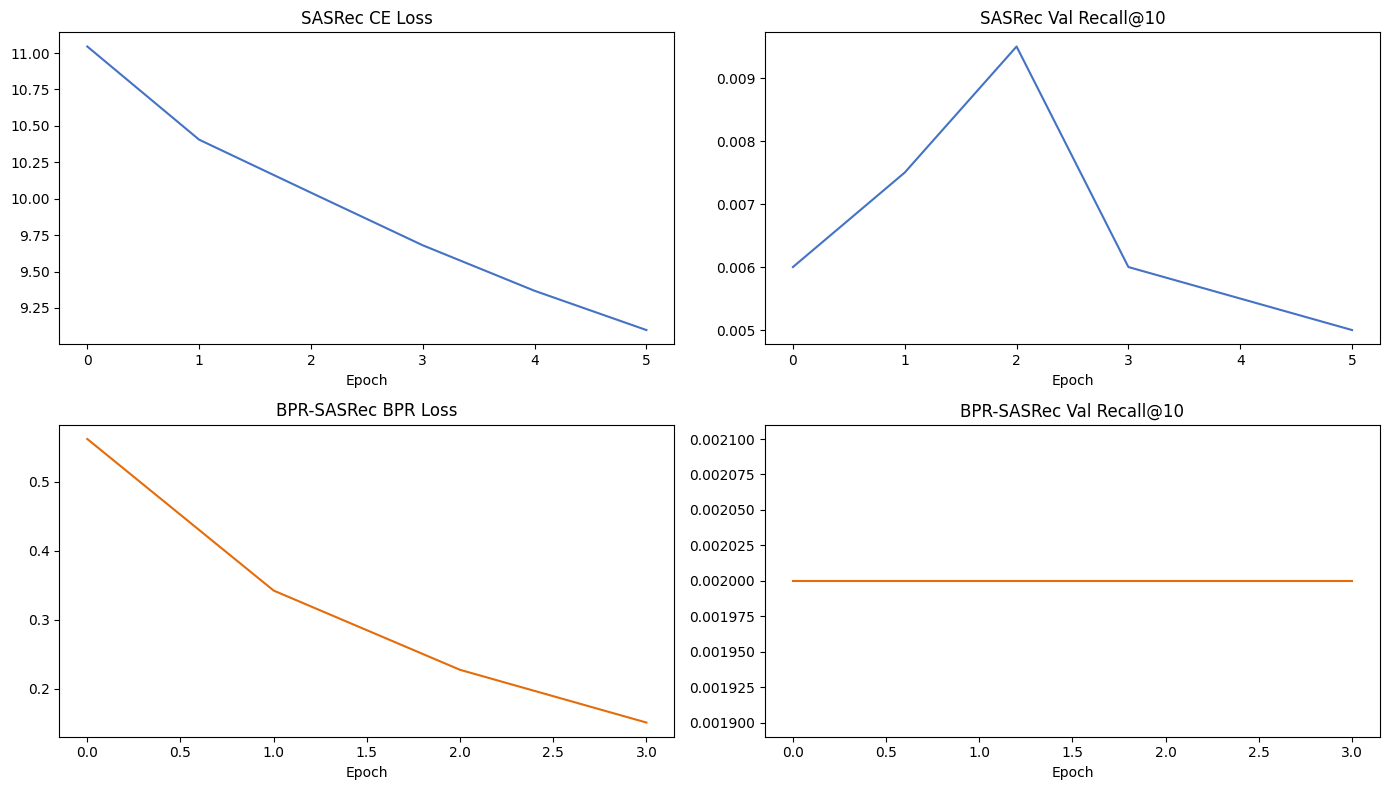

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(sas_history["loss"],      color="#4472C4"); axes[0,0].set_title("SASRec CE Loss")
axes[0,1].plot(sas_history["val_recall"],color="#4472C4"); axes[0,1].set_title("SASRec Val Recall@10")
axes[1,0].plot(bpr_history["loss"],      color="#E46C0A"); axes[1,0].set_title("BPR-SASRec BPR Loss")
axes[1,1].plot(bpr_history["val_recall"],color="#E46C0A"); axes[1,1].set_title("BPR-SASRec Val Recall@10")
for ax in axes.flat:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(ARTIFACTS + "sasrec_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.7 Final Comparison

Section 6.7 produces the final head-to-head comparison of all five model configurations:

1. **Summary table**: Prints Recall@10/20/50 and NDCG@20 for LightGCN alone, SASRec standalone, BPR-SASRec standalone, and the two two-stage pipelines (LightGCN → SASRec, LightGCN → BPR-SASRec). It also reports the relative improvement of each two-stage pipeline over the LightGCN baseline, and whether adding video/user features (BPR-SASRec) helps over the ID-only SASRec.

2. **Bar chart**: Visualises Recall, NDCG, and Precision at K = 10, 20, 50 across all five systems, making it easy to see which model/pipeline performs best at each cut-off.

Together, these outputs answer the central research question: *Does a two-stage pipeline (collaborative filtering retrieval → sequential re-ranking) outperform either stage alone, and do side features further improve sequential recommendation?*

In [ ]:
K_LIST = [10, 20, 50]
systems = [
    ("LightGCN alone (Stage 1)",           lgn_results,            len(first_test)),
    ("SASRec ID-only standalone",          sas_results,            len(first_test)),
    ("BPR-SASRec standalone",              bpr_standalone_results, len(first_test_bpr)),
    ("Two-Stage: LightGCN → SASRec",       lgn_sas_results,        len(first_test)),
    ("Two-Stage: LightGCN → BPR-SASRec",   lgn_bpr_results,        len(first_test_bpr)),
]

print("\n" + "="*78)
print(f"{'Model':<42}  {'R@10':>6}  {'R@20':>6}  {'R@50':>6}  {'N@20':>6}  {'n':>6}")
print("-"*78)
for name, res, n in systems:
    print(f"{name:<42}  "
          f"{res[10]['Recall']:>6.4f}  "
          f"{res[20]['Recall']:>6.4f}  "
          f"{res[50]['Recall']:>6.4f}  "
          f"{res[20]['NDCG']:>6.4f}  "
          f"{n:>6}")
print("="*78)

# ── Key comparison: does SASRec re-ranking improve over LightGCN? ──
print("\nRelative improvement @ K=20:")
base = lgn_results[20]['Recall']
for name, res, _ in systems[3:]:
    delta = (res[20]['Recall'] - base) / base * 100 if base > 0 else 0
    print(f"  {name}: {delta:+.1f}% vs LightGCN alone")

# ── Key comparison: does feature enhancement help? ──
sas_r20  = sas_results[20]['Recall']
bpr_r20  = bpr_standalone_results[20]['Recall']
delta_fe = (bpr_r20 - sas_r20) / sas_r20 * 100 if sas_r20 > 0 else 0
print(f"\nBPR-SASRec vs SASRec standalone @ R@20: {delta_fe:+.1f}%")
print("(Positive = video features help sequential recommendation)")


Model                                         R@10    R@20    R@50    N@20       n
------------------------------------------------------------------------------
LightGCN alone (Stage 1)                    0.0048  0.0081  0.0161  0.0033    6075
SASRec ID-only standalone                   0.0018  0.0036  0.0097  0.0013    6075
BPR-SASRec standalone                       0.0011  0.0035  0.0121  0.0012    3719
Two-Stage: LightGCN → SASRec                0.0051  0.0094  0.0176  0.0040    6075
Two-Stage: LightGCN → BPR-SASRec            0.0051  0.0118  0.0247  0.0046    3719

Relative improvement @ K=20:
  Two-Stage: LightGCN → SASRec: +16.3% vs LightGCN alone
  Two-Stage: LightGCN → BPR-SASRec: +46.7% vs LightGCN alone

BPR-SASRec vs SASRec standalone @ R@20: -3.5%
(Positive = video features help sequential recommendation)


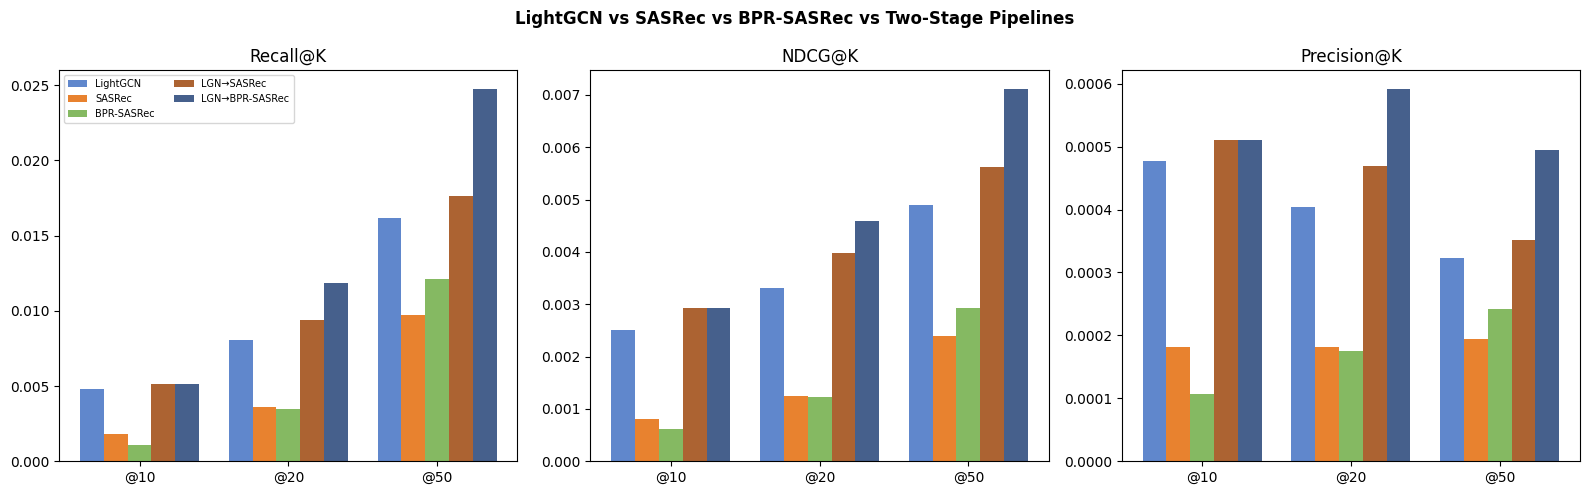

In [ ]:
# ── Bar chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
K_plot  = [10, 20, 50]
plot_systems = [
    ("LightGCN",        lgn_results,            "#4472C4"),
    ("SASRec",          sas_results,            "#E46C0A"),
    ("BPR-SASRec",      bpr_standalone_results, "#70AD47"),
    ("LGN→SASRec",      lgn_sas_results,        "#9E480E"),
    ("LGN→BPR-SASRec",  lgn_bpr_results,        "#264478"),
]
w = 0.16
for ax, metric in zip(axes, ["Recall", "NDCG", "Precision"]):
    for ki, K in enumerate(K_plot):
        for li, (lbl, res, col) in enumerate(plot_systems):
            ax.bar(ki * 1.0 + li * w, res[K][metric], w, color=col,
                   label=lbl if ki == 0 else "", alpha=0.85)
    ax.set_xticks([0.32, 1.32, 2.32])
    ax.set_xticklabels([f"@{K}" for K in K_plot])
    ax.set_title(f"{metric}@K")
    if metric == "Recall": ax.legend(fontsize=7, ncol=2)

plt.suptitle("LightGCN vs SASRec vs BPR-SASRec vs Two-Stage Pipelines",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACTS + "comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()